In [1]:
import os, h5py, numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU: []


In [7]:
IMG_DIR  = "TrainData/img"
MASK_DIR = "TrainData/mask"

img_files  = sorted(os.listdir(IMG_DIR))
mask_files = sorted(os.listdir(MASK_DIR))

print(f"Images found : {len(img_files)}")
print(f"Masks  found : {len(mask_files)}")
print(f"First image  : {img_files[0]}")
print(f"First mask   : {mask_files[0]}")

# Sanity check — filenames must match

#assert img_files == mask_files, "Mismatch between img and mask filenames!"
#print("\n✓ All filenames match")

Images found : 3799
Masks  found : 3799
First image  : image_1.h5
First mask   : mask_1.h5


In [17]:
import os, h5py
import numpy as np
import tensorflow as tf

IMG_DIR  = "TrainData/img"
MASK_DIR = "TrainData/mask"
IMG_SIZE = 64      # resize target

# Known key names used across Landslide4Sense versions
IMG_KEYS  = ['img', 'image', 'data', 'sen2', 'x', 'X']
MASK_KEYS = ['mask', 'label', 'gt', 'y', 'Y']

def read_h5(path, candidate_keys):
    """Open an h5 file and return the first array that matches a key."""
    with h5py.File(path, 'r') as f:
        available = list(f.keys())
        for key in candidate_keys:
            if key in f:
                return f[key][:]
        # If none matched, just load the first dataset found
        for key in available:
            if hasattr(f[key], 'shape'):
                print(f"  [fallback] using key '{key}' in {os.path.basename(path)}")
                return f[key][:]
        raise KeyError(f"No array found in {path}. Keys: {available}")

def fix_image_shape(arr):
    """
    Ensure image is (H, W, C).
    Handles: (H,W,C), (C,H,W), (H,W) — grayscale
    """
    arr = arr.astype(np.float32)
    if arr.ndim == 2:
        # Grayscale → repeat to 3 channels
        arr = np.stack([arr]*3, axis=-1)
    elif arr.ndim == 3:
        # If channels-first: (C,H,W) → (H,W,C)
        if arr.shape[0] < arr.shape[-1]:
            arr = np.transpose(arr, (1, 2, 0))
        # Pick 3 bands: NIR(3), Red(2), Green(1) if ≥4 bands, else first 3
        if arr.shape[-1] >= 4:
            arr = arr[:, :, [3, 2, 1]]
        elif arr.shape[-1] > 3:
            arr = arr[:, :, :3]
        elif arr.shape[-1] < 3:
            # Fewer than 3 channels — pad by repeating last
            pad = 3 - arr.shape[-1]
            arr = np.concatenate([arr] + [arr[:,:,-1:]] * pad, axis=-1)
    return arr   # shape: (H, W, 3)

def fix_mask_shape(arr):
    """Flatten mask to 2D (H, W)."""
    arr = arr.squeeze()       # remove any size-1 dims
    if arr.ndim > 2:
        arr = arr[0]          # take first channel if still 3D
    return arr

# ── Main loading loop ─────────────────────────────────────────────
img_files  = sorted(os.listdir(IMG_DIR))
mask_files = sorted(os.listdir(MASK_DIR))

images, labels = [], []
errors = []

for i, (img_fname, mask_fname) in enumerate(zip(img_files, mask_files)):
    img_path  = os.path.join(IMG_DIR,  img_fname)
    mask_path = os.path.join(MASK_DIR, mask_fname)

    try:
        raw_img  = read_h5(img_path,  IMG_KEYS)
        raw_mask = read_h5(mask_path, MASK_KEYS)

        img  = fix_image_shape(raw_img)
        mask = fix_mask_shape(raw_mask)

        # Binary label: any landslide pixel → 1
        label = 1 if mask.max() > 0 else 0

        images.append(img)
        labels.append(label)

    except Exception as e:
        errors.append((img_fname, str(e)))
        if len(errors) <= 5:        # print first 5 errors only
            print(f"[ERROR] {img_fname}: {e}")

    if (i+1) % 500 == 0:
        print(f"  Loaded {i+1}/{len(img_files)} ...")

images = np.array(images, dtype=np.float32)
labels = np.array(labels, dtype=np.int32)

print(f"\n✓ Loaded : {len(images)} / {len(img_files)} samples")
print(f"  Errors  : {len(errors)}")
print(f"  Shape   : {images.shape}")
print(f"  Labels  : {np.bincount(labels)}  (0=no landslide, 1=landslide)")
print(f"  Pixel range before norm: [{images.min():.3f}, {images.max():.3f}]")

  Loaded 500/3799 ...
  Loaded 1000/3799 ...
  Loaded 1500/3799 ...
  Loaded 2000/3799 ...
  Loaded 2500/3799 ...
  Loaded 3000/3799 ...
  Loaded 3500/3799 ...

✓ Loaded : 3799 / 3799 samples
  Errors  : 0
  Shape   : (3799, 128, 128, 3)
  Labels  : [1568 2231]  (0=no landslide, 1=landslide)
  Pixel range before norm: [0.000, 33.160]


In [23]:
#Normalize & Resize

After resize : (3799, 64, 64, 3)
Pixel range  : [0.005, 0.848]


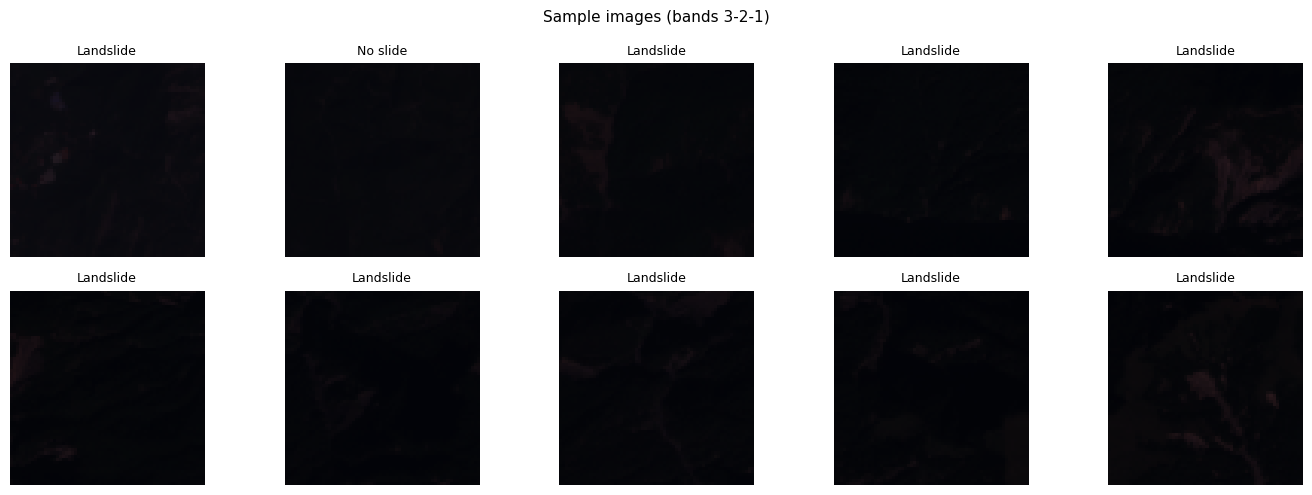

In [25]:
IMG_SIZE = 64

# Replace NaN / Inf common in satellite data
images = np.nan_to_num(images, nan=0.0, posinf=1.0, neginf=0.0)

# Per-channel min-max normalization to [0, 1]
for c in range(images.shape[-1]):
    ch = images[:, :, :, c]
    mn, mx = ch.min(), ch.max()
    if mx > mn:
        images[:, :, :, c] = (ch - mn) / (mx - mn)

# Resize using TF (keeps things on CPU nicely)
images = tf.image.resize(images, [IMG_SIZE, IMG_SIZE]).numpy()

print(f"After resize : {images.shape}")
print(f"Pixel range  : [{images.min():.3f}, {images.max():.3f}]")

# Quick visual check
fig, axes = plt.subplots(2, 5, figsize=(14, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i])
    ax.set_title(f"{'Landslide' if labels[i] else 'No slide'}", fontsize=9)
    ax.axis('off')
plt.suptitle("Sample images (bands 3-2-1)", fontsize=11)
plt.tight_layout()
plt.show()

In [27]:
X_train_img, X_val_img, y_train_img, y_val_img = train_test_split(
    images, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels        # keep class ratio equal in both splits
)

print(f"Train : {X_train_img.shape}  labels: {np.bincount(y_train_img)}")
print(f"Val   : {X_val_img.shape}   labels: {np.bincount(y_val_img)}")

Train : (3039, 64, 64, 3)  labels: [1254 1785]
Val   : (760, 64, 64, 3)   labels: [314 446]


In [31]:
# train 

In [33]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_img)
weights = compute_class_weight('balanced', classes=classes, y=y_train_img)
class_weight = dict(zip(classes.tolist(), weights.tolist()))

print("Class weights:", class_weight)
# e.g. {0: 0.6, 1: 2.1} → landslide class gets 3.5x more penalty

Class weights: {0: 1.2117224880382775, 1: 0.8512605042016806}


In [35]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import Model, Input
from tensorflow.keras.optimizers import Adam

IMG_SIZE = 64

def build_model(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    base = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )
    base.trainable = False          # frozen for phase 1

    inp = Input(shape=input_shape)
    x = base(inp, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inp, out)
    model.compile(
        optimizer=Adam(1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

cnn_model = build_model()
cnn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 64, 64, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 2, 2, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,218,788 (16.09 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [37]:
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

augment_layer = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
], name="augmentation")

def make_ds(X, y, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (X.astype(np.float32), y.astype(np.float32))
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=42)
    if augment:
        ds = ds.map(
            lambda img, lbl: (augment_layer(img, training=True), lbl),
            num_parallel_calls=AUTOTUNE
        )
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_ds(X_train_img, y_train_img, augment=True,  shuffle=True)
val_ds   = make_ds(X_val_img,   y_val_img,   augment=False, shuffle=False)

print("Train batches:", len(train_ds))
print("Val   batches:", len(val_ds))

Train batches: 95
Val   batches: 24


=== LABEL CHECK ===
y_train unique values : (array([0, 1]), array([1254, 1785], dtype=int64))
y_val   unique values : (array([0, 1]), array([314, 446], dtype=int64))
y_train dtype         : int32
% landslide in train  : 58.7%

=== IMAGE CHECK ===
images dtype  : float32
images min    : 0.0052
images max    : 0.8484
images mean   : 0.0353
NaN count     : 0
Inf count     : 0

=== IMAGE VARIANCE CHECK ===
Std per image — mean: 0.0126  min: 0.0066  max: 0.0509
Images with std < 0.01 (near-blank): 853

=== MODEL OUTPUT CHECK ===
First 20 predictions : [0.5465 0.5465 0.5465 0.5465 0.5465 0.5465 0.5465 0.5465 0.5465 0.5465
 0.5465 0.5465 0.5465 0.5466 0.5465 0.5465 0.5466 0.5465 0.5465 0.5465]
Are all predictions same? False


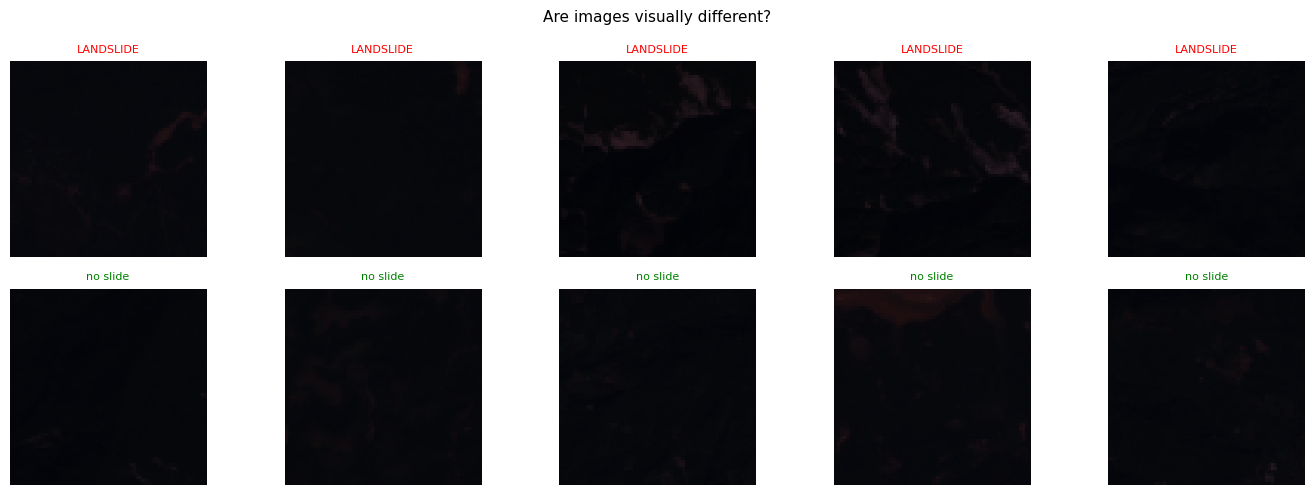

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Label distribution ─────────────────────────────────────────
print("=== LABEL CHECK ===")
print(f"y_train unique values : {np.unique(y_train_img, return_counts=True)}")
print(f"y_val   unique values : {np.unique(y_val_img,   return_counts=True)}")
print(f"y_train dtype         : {y_train_img.dtype}")
print(f"% landslide in train  : {y_train_img.mean()*100:.1f}%")

# ── 2. Image pixel sanity ─────────────────────────────────────────
print("\n=== IMAGE CHECK ===")
print(f"images dtype  : {X_train_img.dtype}")
print(f"images min    : {X_train_img.min():.4f}")
print(f"images max    : {X_train_img.max():.4f}")
print(f"images mean   : {X_train_img.mean():.4f}")
print(f"NaN count     : {np.isnan(X_train_img).sum()}")
print(f"Inf count     : {np.isinf(X_train_img).sum()}")

# ── 3. Are images actually different from each other? ─────────────
print("\n=== IMAGE VARIANCE CHECK ===")
per_image_std = X_train_img.reshape(len(X_train_img), -1).std(axis=1)
print(f"Std per image — mean: {per_image_std.mean():.4f}  "
      f"min: {per_image_std.min():.4f}  max: {per_image_std.max():.4f}")
print(f"Images with std < 0.01 (near-blank): "
      f"{(per_image_std < 0.01).sum()}")

# ── 4. What does the model currently output? ──────────────────────
print("\n=== MODEL OUTPUT CHECK ===")
preds = cnn_model.predict(X_val_img[:20], verbose=0).flatten()
print(f"First 20 predictions : {np.round(preds, 4)}")
print(f"Are all predictions same? {np.allclose(preds, preds[0])}")

# ── 5. Show 5 landslide vs 5 non-landslide images ─────────────────
ls_idx    = np.where(y_train_img == 1)[0][:5]
no_ls_idx = np.where(y_train_img == 0)[0][:5]

fig, axes = plt.subplots(2, 5, figsize=(14, 5))
for i, ax in enumerate(axes[0]):
    ax.imshow(X_train_img[ls_idx[i]])
    ax.set_title("LANDSLIDE", fontsize=8, color='red')
    ax.axis('off')
for i, ax in enumerate(axes[1]):
    ax.imshow(X_train_img[no_ls_idx[i]])
    ax.set_title("no slide", fontsize=8, color='green')
    ax.axis('off')
plt.suptitle("Are images visually different?", fontsize=11)
plt.tight_layout(); plt.show()

In [39]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_auc', patience=6,
                  restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', patience=3,
                      factor=0.5, min_lr=1e-6),
    ModelCheckpoint('best_cnn.h5', monitor='val_auc',
                    save_best_only=True, mode='max')
]

print("=== Phase 1: training classifier head (base frozen) ===")
history1 = cnn_model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=callbacks,
    class_weight=class_weight
)

results1 = cnn_model.evaluate(val_ds, verbose=0)
print(f"\nPhase 1 val — loss: {results1[0]:.4f}  "
      f"acc: {results1[1]:.4f}  auc: {results1[2]:.4f}")

=== Phase 1: training classifier head (base frozen) ===
Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.4967 - auc: 0.5083 - loss: 0.8443

95/95 ━━━━━━━━━━━━━━━━━━━━ 32s 156ms/step - accuracy: 0.4968 - auc: 0.5082 - loss: 0.8442 - val_accuracy: 0.5868 - val_auc: 0.5000 - val_loss: 0.6813 - learning_rate: 0.0010
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.4974 - auc: 0.4902 - loss: 0.7952 - val_accuracy: 0.4132 - val_auc: 0.5000 - val_loss: 0.7028 - learning_rate: 0.0010
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - accuracy: 0.5070 - auc: 0.5273 - loss: 0.7332 - val_accuracy: 0.4132 - val_auc: 0.5000 - val_loss: 0.6993 - learning_rate: 0.0010
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - accuracy: 0.4876 - auc: 0.4899 - loss: 0.7489 - val_accuracy: 0.5868 - val_auc: 0.5000 - val_loss: 0.6929 - learning_rate: 0.0010
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - accuracy: 0.5087 - auc: 0.5271 - loss: 0.7196 - val_accuracy: 0.5868 - val_auc: 0.5000 - val_loss: 0.6925 - learning_rate: 5.0000e-04
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.5172 - auc: 0.5

In [45]:
# Phase 2: unfreeze top layers and fine-tune
# (only for EfficientNet version)
try:
    base_model = cnn_model.layers[1]  # EfficientNetB0
    base_model.trainable = True
    
    # Freeze all except last 20 layers
    for layer in base_model.layers[:-20]:
        layer.trainable = False
    
    cnn_model.compile(optimizer=Adam(1e-5),
                      loss='binary_crossentropy',
                      metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    
    cnn_model.fit(train_ds, epochs=10,
                  validation_data=test_ds,
                  callbacks=callbacks)
except:
    print("Skipping fine-tune (lightweight CNN)")



# Save model
cnn_model.save('landslide_cnn.h5')
print("Saved: landslide_cnn.h5")

Skipping fine-tune (lightweight CNN)
Saved: landslide_cnn.h5
